In [8]:
import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format


path = r"C:\Users\Acer\ProjectsPortfolio\OnlineRetail\raw\online_retail_II.csv"

df = pd.read_csv(path, encoding="latin1")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


# EDA

In [20]:
df.shape

(1067371, 8)

In [21]:
df.columns

Index(['invoice', 'stockcode', 'description', 'quantity', 'invoicedate',
       'price', 'customer_id', 'country'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   invoice      1067371 non-null  object        
 1   stockcode    1067371 non-null  object        
 2   description  1062989 non-null  object        
 3   quantity     1067371 non-null  int64         
 4   invoicedate  1067371 non-null  datetime64[ns]
 5   price        1067371 non-null  float64       
 6   customer_id  824364 non-null   float64       
 7   country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [13]:
#fehlende Werte
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [23]:
#Duplikatsprüfung
df.duplicated().sum()

np.int64(34335)

In [24]:
#Dtype
df.dtypes

invoice                object
stockcode              object
description            object
quantity                int64
invoicedate    datetime64[ns]
price                 float64
customer_id           float64
country                object
dtype: object

In [25]:
# statistics
df.describe()

,quantity,invoicedate,price,customer_id
count,"1,067,371.00",1067371,"1,067,371.00","824,364.00"
mean,9.94,2011-01-02 21:13:55.394028544,4.65,"15,324.64"
min,"-80,995.00",2009-12-01 07:45:00,"-53,594.36","12,346.00"
25%,1.00,2010-07-09 09:46:00,1.25,"13,975.00"
50%,3.00,2010-12-07 15:28:00,2.10,"15,255.00"
75%,10.00,2011-07-22 10:23:00,4.15,"16,797.00"
max,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00"
std,172.71,NaN,123.55,"1,697.46"


In [26]:
#Data Range
df['invoicedate'].min(), df['invoicedate'].max()

(Timestamp('2009-12-01 07:45:00'), Timestamp('2011-12-09 12:50:00'))

In [14]:
#Spaltennormalisierung
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

In [15]:
df.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


In [27]:
print("Original dataset:", df.shape)

Original dataset: (1067371, 8)


# Datenbereinigung

In [30]:
df_cleaned = df.copy()

In [31]:
# remove duplicates
df_cleaned = df_cleaned.drop_duplicates()

In [32]:
# remove missing customer_id
df_cleaned = df_cleaned[df_cleaned['customer_id'].notnull()]

In [35]:
# remove cancelled orders
df_cleaned = df_cleaned[~df_cleaned['invoice'].astype(str).str.startswith('C')]

In [36]:
# remove returns
df_cleaned = df_cleaned[df_cleaned['quantity'] > 0]

In [37]:
# remove invalid prices
df_cleaned = df_cleaned[df_cleaned['price'] > 0]

In [40]:
rows_removed = df.shape[0] - df_cleaned.shape[0]

print("Original dataset:", df.shape)
print("Rows removed:", rows_removed)
print("Cleaned dataset:", df_cleaned.shape)

Original dataset: (1067371, 8)
Rows removed: 287946
Cleaned dataset: (779425, 8)


In [44]:
#Check
print("Rows:", df_cleaned.shape)
print("Customers:", df_cleaned['customer_id'].nunique())
print("Date range:", df_cleaned['invoicedate'].min(), "-", df_cleaned['invoicedate'].max())

Rows: (779425, 9)
Customers: 5878
Date range: 2009-12-01 07:45:00 - 2011-12-09 12:50:00


# Feature engineering

In [42]:
#Revenue
df_cleaned['revenue'] = df_cleaned['quantity'] * df_cleaned['price']
df_cleaned[['quantity','price','revenue']].head()

,quantity,price,revenue
0,12,6.95,83.40
1,12,6.75,81.00
2,12,6.75,81.00
3,48,2.10,100.80
4,24,1.25,30.00


# Business EDA

<Axes: xlabel='invoicedate'>

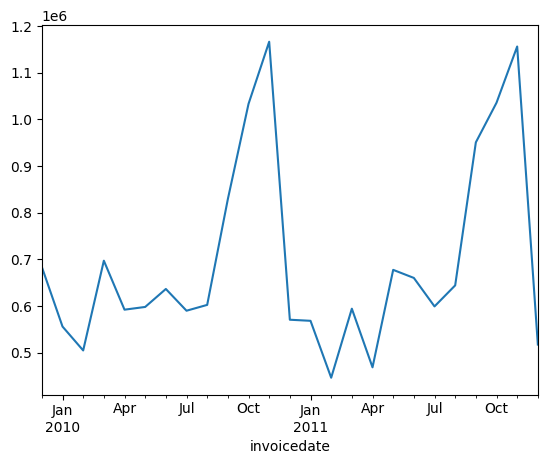

In [45]:
#Revenue over time
revenue_time = df_cleaned.groupby(df_cleaned['invoicedate'].dt.to_period('M'))['revenue'].sum()
revenue_time.plot()

<Axes: xlabel='country'>

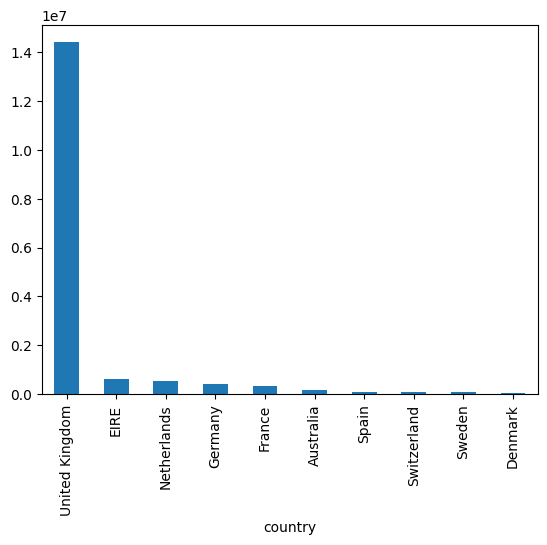

In [46]:
#Top Countries
country_revenue = df_cleaned.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)
country_revenue.plot(kind='bar')

In [47]:
#Orders per Customer
orders_per_customer = df_cleaned.groupby('customer_id')['invoice'].nunique()
orders_per_customer.describe()

count   5,878.00
mean        6.29
std        13.01
min         1.00
25%         1.00
50%         3.00
75%         7.00
max       398.00
Name: invoice, dtype: float64

# Cohort Dataset

In [51]:
#Cohort Month (first purchase)
df_cleaned['cohort_month'] = df_cleaned.groupby('customer_id')['invoicedate'] \
                                       .transform('min') \
                                       .dt.to_period('M')

In [52]:
#Order Month
df_cleaned['order_month'] = df_cleaned['invoicedate'].dt.to_period('M')

In [53]:
#Cohort Index (Anzahl der Monate seit dem Erstkauf)
df_cleaned['cohort_index'] = (
    (df_cleaned['order_month'].dt.year - df_cleaned['cohort_month'].dt.year) * 12 +
    (df_cleaned['order_month'].dt.month - df_cleaned['cohort_month'].dt.month)
)

In [57]:
#Create Cohort Table (Aggregation der Nutzer)
cohort_data = df_cleaned.groupby(['cohort_month','cohort_index'])['customer_id'].nunique().reset_index()
cohort_data 

,cohort_month,cohort_index,customer_id
0,2009-12,0,955
1,2009-12,1,337
2,2009-12,2,319
3,2009-12,3,406
4,2009-12,4,363
...,...,...,...
320,2011-10,1,71
321,2011-10,2,35
322,2011-11,0,191
323,2011-11,1,27


In [58]:
#Retention Matrix
cohort_pivot = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_id'
)
cohort_pivot

cohort_index,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
cohort_month,,,,,,,,,,,,,,,,,,,,,
2009-12,955.00,337.00,319.00,406.00,363.00,343.00,360.00,327.00,321.00,346.00,...,289.00,251.00,289.00,270.00,248.00,244.00,301.00,291.00,389.00,188.00
2010-01,383.00,79.00,119.00,117.00,101.00,115.00,99.00,88.00,107.00,122.00,...,58.00,90.00,76.00,71.00,75.00,93.00,74.00,94.00,22.00,NaN
2010-02,374.00,89.00,84.00,109.00,92.00,75.00,72.00,107.00,95.00,103.00,...,75.00,60.00,61.00,54.00,86.00,86.00,61.00,22.00,NaN,NaN
2010-03,443.00,84.00,102.00,107.00,103.00,90.00,109.00,134.00,122.00,48.00,...,75.00,77.00,69.00,78.00,89.00,94.00,35.00,NaN,NaN,NaN
2010-04,294.00,57.00,57.00,48.00,54.00,66.00,81.00,77.00,31.00,32.00,...,46.00,41.00,44.00,53.00,66.00,17.00,NaN,NaN,NaN,NaN
2010-05,254.00,40.00,43.00,44.00,45.00,65.00,54.00,32.00,15.00,21.00,...,32.00,35.00,42.00,39.00,12.00,NaN,NaN,NaN,NaN,NaN
2010-06,270.00,47.00,51.00,55.00,62.00,77.00,34.00,24.00,22.00,32.00,...,33.00,36.00,55.00,14.00,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.00,29.00,34.00,55.00,54.00,26.00,21.00,27.00,27.00,21.00,...,32.00,44.00,15.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.00,33.00,48.00,52.00,28.00,19.00,16.00,20.00,22.00,21.00,...,32.00,11.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
#Retention Rate
#(for row in cohort:
#    row = row / row[0])

retention = cohort_pivot.divide(cohort_pivot[0], axis=0)
retention

cohort_index,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
cohort_month,,,,,,,,,,,,,,,,,,,,,
2009-12,1.00,0.35,0.33,0.43,0.38,0.36,0.38,0.34,0.34,0.36,...,0.30,0.26,0.30,0.28,0.26,0.26,0.32,0.30,0.41,0.20
2010-01,1.00,0.21,0.31,0.31,0.26,0.30,0.26,0.23,0.28,0.32,...,0.15,0.23,0.20,0.19,0.20,0.24,0.19,0.25,0.06,NaN
2010-02,1.00,0.24,0.22,0.29,0.25,0.20,0.19,0.29,0.25,0.28,...,0.20,0.16,0.16,0.14,0.23,0.23,0.16,0.06,NaN,NaN
2010-03,1.00,0.19,0.23,0.24,0.23,0.20,0.25,0.30,0.28,0.11,...,0.17,0.17,0.16,0.18,0.20,0.21,0.08,NaN,NaN,NaN
2010-04,1.00,0.19,0.19,0.16,0.18,0.22,0.28,0.26,0.11,0.11,...,0.16,0.14,0.15,0.18,0.22,0.06,NaN,NaN,NaN,NaN
2010-05,1.00,0.16,0.17,0.17,0.18,0.26,0.21,0.13,0.06,0.08,...,0.13,0.14,0.17,0.15,0.05,NaN,NaN,NaN,NaN,NaN
2010-06,1.00,0.17,0.19,0.20,0.23,0.29,0.13,0.09,0.08,0.12,...,0.12,0.13,0.20,0.05,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,1.00,0.16,0.18,0.30,0.29,0.14,0.11,0.15,0.15,0.11,...,0.17,0.24,0.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.00,0.20,0.30,0.32,0.17,0.12,0.10,0.12,0.14,0.13,...,0.20,0.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
#Check
df_cleaned[['customer_id','invoicedate','cohort_month','order_month','cohort_index']].head(10)

,customer_id,invoicedate,cohort_month,order_month,cohort_index
0,"13,085.00",2009-12-01 07:45:00,2009-12,2009-12,0
1,"13,085.00",2009-12-01 07:45:00,2009-12,2009-12,0
2,"13,085.00",2009-12-01 07:45:00,2009-12,2009-12,0
3,"13,085.00",2009-12-01 07:45:00,2009-12,2009-12,0
4,"13,085.00",2009-12-01 07:45:00,2009-12,2009-12,0
5,"13,085.00",2009-12-01 07:45:00,2009-12,2009-12,0
6,"13,085.00",2009-12-01 07:45:00,2009-12,2009-12,0
7,"13,085.00",2009-12-01 07:45:00,2009-12,2009-12,0
8,"13,085.00",2009-12-01 07:46:00,2009-12,2009-12,0
9,"13,085.00",2009-12-01 07:46:00,2009-12,2009-12,0


In [64]:
#for heatmap
df_cleaned['cohort_month'] = df_cleaned['cohort_month'].astype(str)
df_cleaned['order_month'] = df_cleaned['order_month'].astype(str)

In [66]:
#for Tableau
df_cleaned.to_csv("cohort_dataset.csv", index=False)